# ModC Week 3 — Linear Regression 3 (Selection & Dimensionality Reduction)

**Domain:** Marketing Conversion Propensity 
**Datasets:** Google Ads Sales; Predict Conversion in Digital Marketing

Forward/backward stepwise selection, PCR, and PLSR to compare feature selection and dimensionality reduction on marketing data.

## 1. Imports and Data Loading

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 110

def find_data_root() -> Path:
    marker = 'marketing_and_product_performance.csv'
    for base in [Path.cwd(), *Path.cwd().parents]:
        data_dir = base / 'data'
        if (data_dir / marker).exists():
            return data_dir
    return Path('data')

DATA_ROOT = find_data_root()

DATASET_PATHS = {
    'Marketing and Product Performance': DATA_ROOT / 'marketing_and_product_performance.csv',
    'Predict Conversion in Digital Marketing': DATA_ROOT / 'digital_marketing_campaign_dataset.csv',
    'Google Ads Sales': DATA_ROOT / 'GoogleAds_DataAnalytics_Sales_Uncleaned.csv',
}

def load_dataset(name: str) -> pd.DataFrame:
    path = DATASET_PATHS[name]
    if not path.exists():
        raise FileNotFoundError(
            f"Missing file for '{name}': {path.resolve()}\n"
            f"Current working directory: {Path.cwd()}\n"
            f"Run: python download_datasets.py"
        )
    df = pd.read_csv(path)
    print(f'{name} loaded: {path.name} | shape={df.shape}')
    return df

def pick_column(df, candidates):
    lower_map = {c.lower().replace(' ', '_'): c for c in df.columns}
    for cand in candidates:
        key = cand.lower().replace(' ', '_')
        if key in lower_map:
            return lower_map[key]
    for col in df.columns:
        norm = col.lower().replace(' ', '_')
        if any(cand.lower().replace(' ', '_') in norm for cand in candidates):
            return col
    return None

def regression_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {'R2': r2_score(y_true, y_pred), 'RMSE': rmse}

def clean_currency(series):
    if series.dtype == object:
        return pd.to_numeric(
            series.astype(str).str.replace(r'[\$,]', '', regex=True),
            errors='coerce',
        )
    return series

def prepare_google_ads_sales(df):
    # Prepare Google Ads Sales for continuous regression (target: Conversions).
    prepared = df.copy()
    for col in ['Cost', 'Sale_Amount']:
        if col in prepared.columns:
            prepared[col] = clean_currency(prepared[col])

    target_col = pick_column(prepared, ['Conversions', 'Leads', 'Conversion Rate', 'Sale_Amount'])
    if target_col is None or prepared[target_col].notna().sum() < 100:
        raise ValueError('Could not find a suitable regression target in Google Ads Sales.')
    return prepared, target_col

def build_feature_matrix(df, target_col, max_cat_levels=12):
    model_df = df.dropna(subset=[target_col]).copy()
    id_cols = [c for c in model_df.columns if c.lower().endswith('_id') or c.lower() == 'ad_id']
    model_df = model_df.drop(columns=[c for c in id_cols if c != target_col], errors='ignore')
    leakage_cols = ['Conversion Rate', 'Sale_Amount']
    model_df = model_df.drop(columns=[c for c in leakage_cols if c in model_df.columns], errors='ignore')

    cat_cols = model_df.select_dtypes(include=['object', 'category']).columns.tolist()
    for col in cat_cols:
        if col != target_col and model_df[col].nunique() <= max_cat_levels:
            model_df = pd.concat([
                model_df.drop(columns=[col]),
                pd.get_dummies(model_df[col], prefix=col, drop_first=True),
            ], axis=1)

    X = model_df.drop(columns=[target_col]).select_dtypes(include=[np.number])
    X = X.fillna(X.median(numeric_only=True))
    y = model_df[target_col]
    return X, y

google_ads_sales = load_dataset('Google Ads Sales')
predict_conversion = load_dataset('Predict Conversion in Digital Marketing')

Google Ads Sales loaded: GoogleAds_DataAnalytics_Sales_Uncleaned.csv | shape=(2600, 13)
Predict Conversion in Digital Marketing loaded: digital_marketing_campaign_dataset.csv | shape=(8000, 20)


## 2. EDA and Feature Preview

Dataset: Google Ads Sales | Target: Conversions


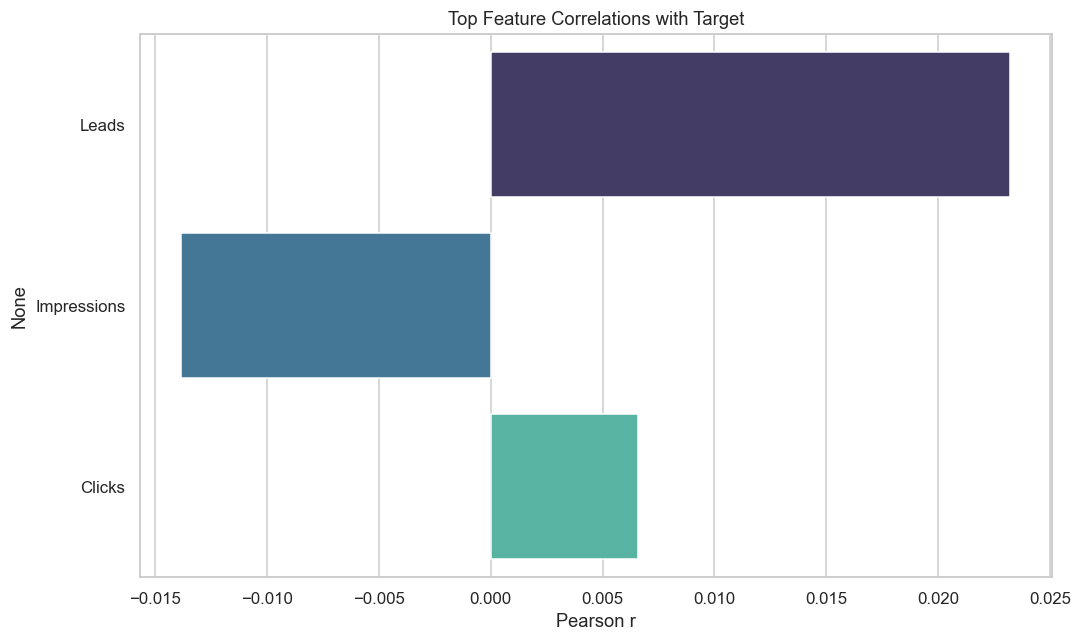

In [2]:

df, target_col = prepare_google_ads_sales(google_ads_sales)
print(f'Dataset: Google Ads Sales | Target: {target_col}')

X, y = build_feature_matrix(df, target_col)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

plt.figure(figsize=(10, 6))
corr_target = X.corrwith(y).sort_values(key=abs, ascending=False).head(12)
sns.barplot(x=corr_target.values, y=corr_target.index, palette='mako')
plt.title('Top Feature Correlations with Target')
plt.xlabel('Pearson r')
plt.tight_layout()
plt.show()


## 3. Forward Stepwise Selection

In [3]:

from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.linear_model import LinearRegression

forward = SFS(
    LinearRegression(),
    k_features=min(8, X_train.shape[1]),
    forward=True,
    floating=False,
    scoring='r2',
    cv=5,
    n_jobs=-1,
)
forward.fit(X_train.values, y_train.values)
forward_features = list(X.columns[list(forward.k_feature_idx_)])
print('Forward-selected features:', forward_features)

lr_forward = LinearRegression().fit(X_train[forward_features], y_train)
metrics_forward = regression_metrics(y_test, lr_forward.predict(X_test[forward_features]))
print('Forward selection test metrics:', metrics_forward)


Forward-selected features: ['Clicks', 'Impressions', 'Leads']
Forward selection test metrics: {'R2': -0.006300730800318011, 'RMSE': np.float64(2.293582967748235)}


## 4. Backward Stepwise Selection

In [4]:

backward = SFS(
    LinearRegression(),
    k_features=min(8, X_train.shape[1]),
    forward=False,
    floating=False,
    scoring='r2',
    cv=5,
    n_jobs=-1,
)
backward.fit(X_train.values, y_train.values)
backward_features = list(X.columns[list(backward.k_feature_idx_)])
print('Backward-selected features:', backward_features)

lr_backward = LinearRegression().fit(X_train[backward_features], y_train)
metrics_backward = regression_metrics(y_test, lr_backward.predict(X_test[backward_features]))
print('Backward selection test metrics:', metrics_backward)


Backward-selected features: ['Clicks', 'Impressions', 'Leads']
Backward selection test metrics: {'R2': -0.006300730800318011, 'RMSE': np.float64(2.293582967748235)}


## 5. Principal Component Regression (PCR)

PCR components: 3 | Test metrics: {'R2': -0.006300730800318011, 'RMSE': np.float64(2.293582967748235)}


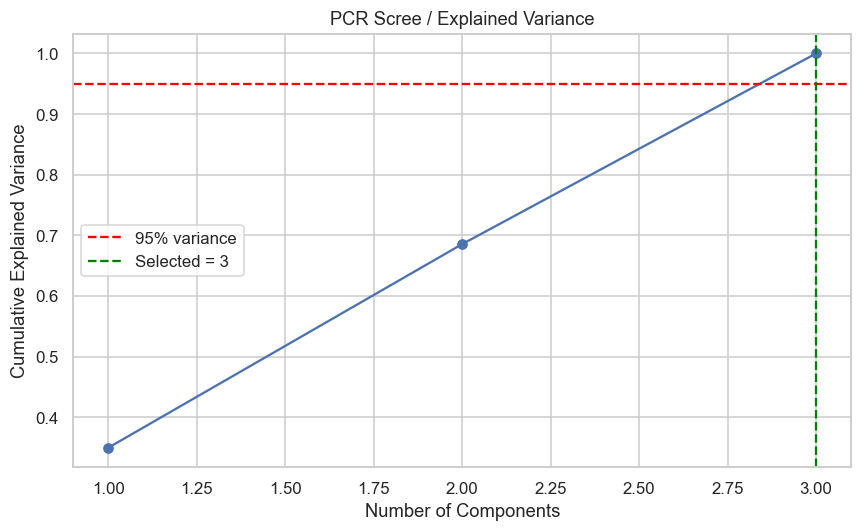

In [5]:

from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pcr = Pipeline([
    ('scale', StandardScaler()),
    ('pca', PCA()),
    ('lr', LinearRegression()),
])

pca_full = Pipeline([('scale', StandardScaler()), ('pca', PCA())])
pca_full.fit(X_train)
explained = np.cumsum(pca_full.named_steps['pca'].explained_variance_ratio_)
n_comp = int(np.searchsorted(explained, 0.95) + 1)
n_comp = max(1, min(n_comp, X_train.shape[1]))

pcr.set_params(pca__n_components=n_comp)
pcr.fit(X_train, y_train)
metrics_pcr = regression_metrics(y_test, pcr.predict(X_test))
print(f'PCR components: {n_comp} | Test metrics:', metrics_pcr)

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained) + 1), explained, marker='o')
plt.axhline(0.95, color='red', linestyle='--', label='95% variance')
plt.axvline(n_comp, color='green', linestyle='--', label=f'Selected = {n_comp}')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCR Scree / Explained Variance')
plt.legend()
plt.tight_layout()
plt.show()


## 6. Partial Least Squares Regression (PLSR)

In [6]:

from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_score

best_n, best_score = 1, -np.inf
for n in range(1, min(10, X_train.shape[1]) + 1):
    pls = PLSRegression(n_components=n)
    scores = cross_val_score(pls, X_train, y_train, cv=5, scoring='r2')
    if scores.mean() > best_score:
        best_score, best_n = scores.mean(), n

pls_best = PLSRegression(n_components=best_n)
pls_best.fit(X_train, y_train)
metrics_pls = regression_metrics(y_test, pls_best.predict(X_test).ravel())
print(f'Best PLS components: {best_n} | CV R²: {best_score:.4f}')
print('PLSR test metrics:', metrics_pls)


Best PLS components: 1 | CV R²: -0.0043
PLSR test metrics: {'R2': -0.006182054061563136, 'RMSE': np.float64(2.293447718431577)}


## 7. Predict Conversion in Digital Marketing — Feature Exploration

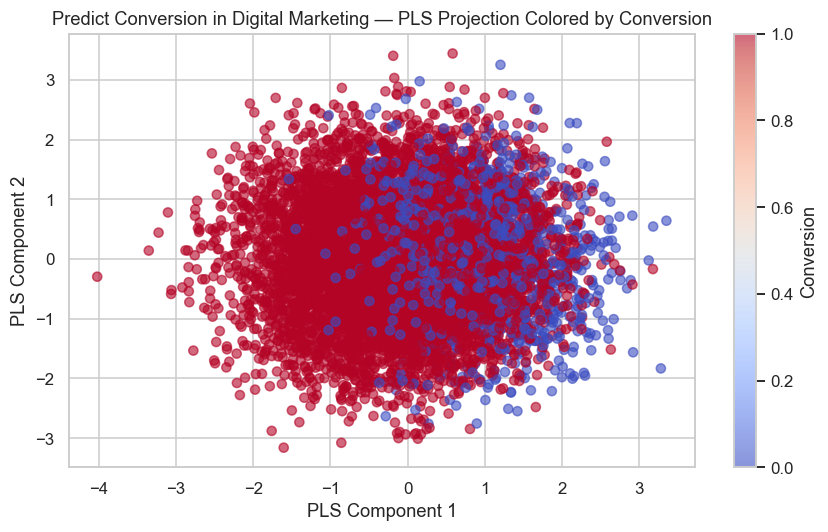

In [7]:

conv_col = pick_column(predict_conversion, ['Conversion', 'Converted', 'conversion'])
if conv_col:
    conv_num = predict_conversion.select_dtypes(include=[np.number])
    if conv_col in conv_num.columns:
        conv_num = conv_num.drop(columns=[conv_col])
    if len(conv_num.columns) > 0:
        y_conv = predict_conversion[conv_col]
        pls_conv = PLSRegression(n_components=min(3, conv_num.shape[1]))
        pls_conv.fit(conv_num.fillna(conv_num.median()), y_conv)
        pls_scores = pls_conv.transform(conv_num.fillna(conv_num.median()))
        plt.figure(figsize=(8, 5))
        plt.scatter(pls_scores[:, 0], pls_scores[:, 1], c=y_conv, cmap='coolwarm', alpha=0.6)
        plt.xlabel('PLS Component 1')
        plt.ylabel('PLS Component 2')
        plt.title('Predict Conversion in Digital Marketing — PLS Projection Colored by Conversion')
        plt.colorbar(label=conv_col)
        plt.tight_layout()
        plt.show()
else:
    print('Conversion column not found in Predict Conversion in Digital Marketing; skipping PLS visualization.')


## 8. Compare All Methods

               Method        R2      RMSE
0   Forward Selection -0.006301  2.293583
1  Backward Selection -0.006301  2.293583
2                 PCR -0.006301  2.293583
3                PLSR -0.006182  2.293448


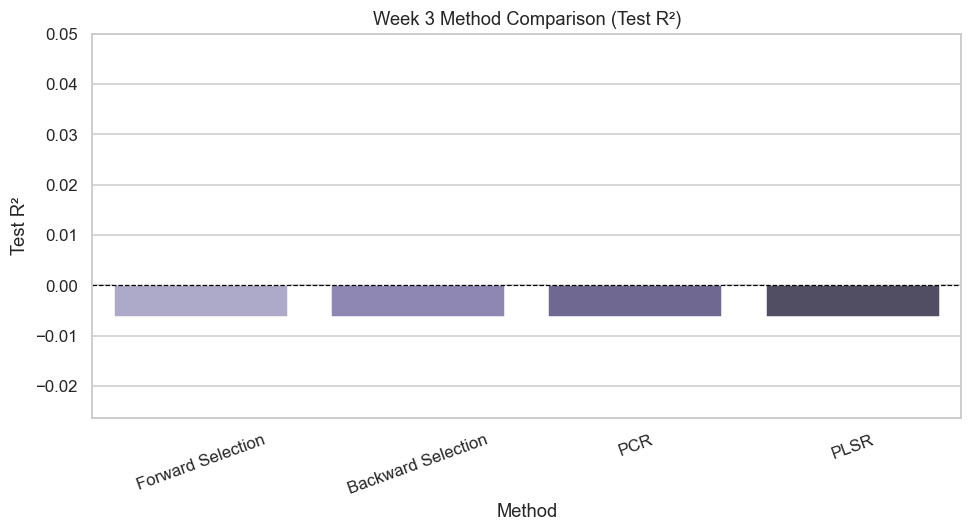

In [8]:

summary = pd.DataFrame([
    {'Method': 'Forward Selection', **metrics_forward},
    {'Method': 'Backward Selection', **metrics_backward},
    {'Method': 'PCR', **metrics_pcr},
    {'Method': 'PLSR', **metrics_pls},
])
print(summary)

FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

r2_min = min(0, summary['R2'].min() - 0.02)
r2_max = max(0.05, summary['R2'].max() + 0.05)

plt.figure(figsize=(9, 5))
sns.barplot(data=summary, x='Method', y='R2', palette='Purples_d')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.ylim(r2_min, r2_max)
plt.title('Week 3 Method Comparison (Test R²)')
plt.xlabel('Method')
plt.ylabel('Test R²')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIG_DIR / 'figure3.png', bbox_inches='tight', dpi=160)
plt.show()


## 9. Conclusions

**Stepwise selection:** Forward and backward selection identify interpretable subsets of campaign features. Differences between the two highlight correlated ad metrics where order of entry/removal matters.

**PCR:** Compresses correlated predictors into orthogonal components, reducing multicollinearity but sacrificing direct feature interpretability. In the Milestone 1 version, the number of components is selected by cross-validated prediction error rather than only by explained variance.

**PLSR:** Supervised dimensionality reduction aligns components with the target. Whether PLSR outperforms PCR should be determined from the model comparison table rather than assumed; in the corrected leakage-free Google Ads regression, neither method shows strong predictive signal.

**Overfitting:** Cross-validation for stepwise scoring and component count helps avoid selecting too many degrees of freedom, but it cannot fix target leakage if target-derived features are included upstream.

**Business value:** Stepwise models support stakeholder-friendly narratives; PLS/PCR support scoring pipelines when feature count is large. For this project, the cleaner predictive story comes from the digital marketing classification task.